Warum nutzt BlackRock Marktanalysen mit Clustering
- verschiedene Marktphasen birgen unterschiedliche Risiken
- BlackRock kann Risiken früher erkennen und Portfolios und Investments anpassen


In [53]:
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

In [54]:
dax = yf.Ticker("^GDAXI")

# DAX von 2018 bs 2024
dax = yf.download("^GDAXI", start="2018-01-01", end="2024-12-31")
dax.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GDAXI,^GDAXI,^GDAXI,^GDAXI,^GDAXI
Date,,,,,
2018-01-02,12871.389648,12924.160156,12745.150391,12897.690430,86049300
2018-01-03,12978.209961,13023.589844,12893.049805,12916.179688,84809300
2018-01-04,13167.889648,13208.349609,13062.669922,13065.980469,101199400
2018-01-05,13319.639648,13332.799805,13219.110352,13219.110352,112555000
2018-01-08,13367.780273,13407.820312,13334.160156,13399.620117,95005300


In [55]:
# Rendite berechnen
# tägliche Prozentuale Veränderung
dax["Rendite"] = dax["Close"].pct_change()

In [56]:
# Volatilität berechnen
dax["Volatilität"] = dax["Rendite"].rolling(window=20).std()

In [57]:
# Dataset bereinigen
dax = dax.dropna()

In [58]:
features = dax[["Rendite","Volatilität" ]]

In [59]:
# Gewichtung der Features gleichwertig machen 
scaler = StandardScaler()
X = np.array(features)
X_scaled = scaler.fit_transform(X)

In [60]:
# Modell
# K_means
# K = 3 (ruhig, mittel, volatil)

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(X_scaled)
dax["Cluster"] = kmeans.labels_
features["Cluster"] = kmeans.labels_

C:\Users\Henri\AppData\Local\Temp\ipykernel_6712\24920093.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Cluster"] = kmeans.labels_


In [61]:
features.groupby("Cluster").mean()


Price,Rendite,Volatilität
Ticker,,
Cluster,,
0,-0.013055,0.011170
1,0.004472,0.009024
2,0.009407,0.028586


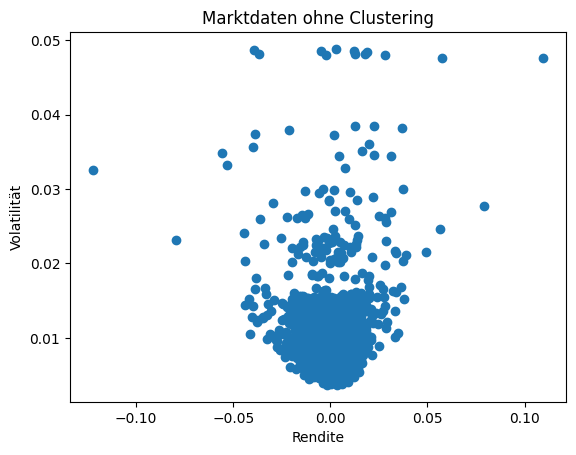

In [62]:

plt.figure()
plt.scatter(features["Rendite"], features["Volatilität"])
plt.xlabel("Rendite")
plt.ylabel("Volatilität")
plt.title("Marktdaten ohne Clustering")
plt.show()

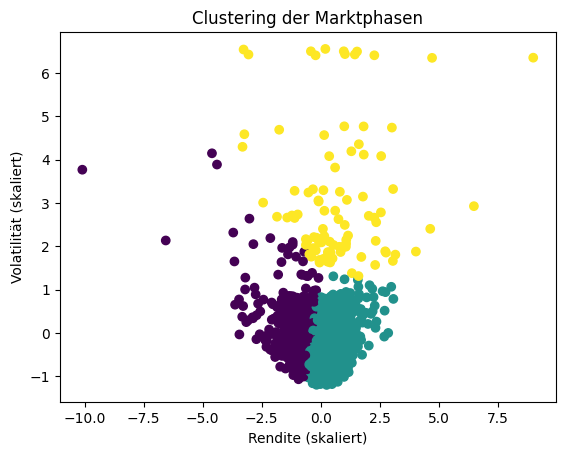

In [63]:
labels = kmeans.labels_

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.xlabel("Rendite (skaliert)")
plt.ylabel("Volatilität (skaliert)")
plt.title("Clustering der Marktphasen")
plt.show()

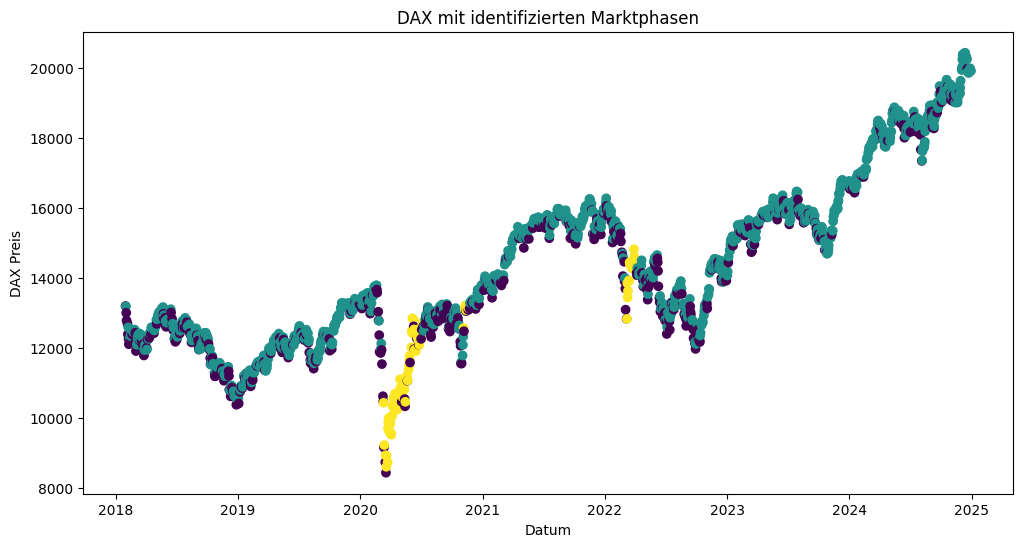

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.scatter(
    dax.index,
    dax["Close"],
    c=dax["Cluster"],
    cmap="viridis"
)

plt.xlabel("Datum")
plt.ylabel("DAX Preis")
plt.title("DAX mit identifizierten Marktphasen")

plt.show()

In [65]:
# Letzte Marktphase einordnen
latestDax = yf.download("^GDAXI", start="2025-01-01", end="2025-12-31")

latestDax["Rendite"] = latestDax["Close"].pct_change()
latestDax["Volatilität"] = latestDax["Rendite"].rolling(window=20).std()

latestDax = latestDax.dropna()

newFeatures = latestDax[["Rendite","Volatilität" ]]

features_scaled = scaler.transform(newFeatures)

kmeans.predict(features_scaled)
latestDax["Cluster"] = kmeans.predict(features_scaled)

[*********************100%***********************]  1 of 1 completed


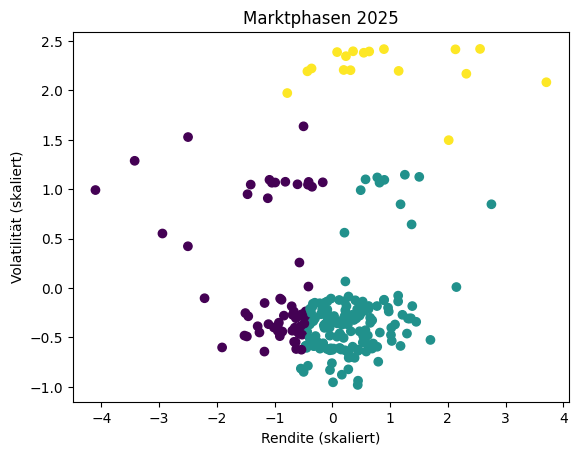

In [66]:
import matplotlib.pyplot as plt

plt.scatter(
    features_scaled[:, 0],
    features_scaled[:, 1],
    c=latestDax["Cluster"]
)
plt.xlabel("Rendite (skaliert)")
plt.ylabel("Volatilität (skaliert)")
plt.title("Marktphasen 2025")
plt.show()
